In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import time
from typing import Tuple
from scipy.optimize import curve_fit
import pickle
# from binding import line_sim as sim
from sim import line_sim, cyclic_sim
from numba import njit, prange

In [2]:
def exponential_func(x, a, b):
    return a * np.exp(-b * x)

def exponential_cdf_func(x, a):
     return 1-np.exp(-a*x)

def get_binding_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==0)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def get_stepping_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==2)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def normalised_cdf_histogramm(data, bins =100, density=True):
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    cdf = np.cumsum(counts)
    M = cdf[-1]
    return bin_edges[1:], cdf/M

def normalised_pdf_histogramm(data, bins =100, density=True):
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    S = np.sum(counts)    
    return (bin_edges[:-1] + bin_edges[1:]) / 2, counts/S



def fit (res, dt, func):   
    # hist, bins = np.histogram(func(res, dt), bins=1000, density=True) 
    # bin_centers = (bins[:-1] + bins[1:]) / 2

    x,y = normalised_pdf_histogramm(func(res, dt))
    params, covariance = curve_fit(exponential_func, x,y)
    return params[1], covariance[1][0]

def fit_cdf(res, dt, func):
    x,y = normalised_cdf_histogramm(func(res, dt), bins=1000)
    params, covariance = curve_fit(exponential_cdf_func, x,y)
    return params[0], covariance[0][0]

In [3]:
q=1

L = 300
T = 100
kon = 1
koff = 1
kstep = 100
kq = 10

In [4]:
data, times, res, dt = cyclic_sim(L, T, kon, koff, kstep, kq, 10)

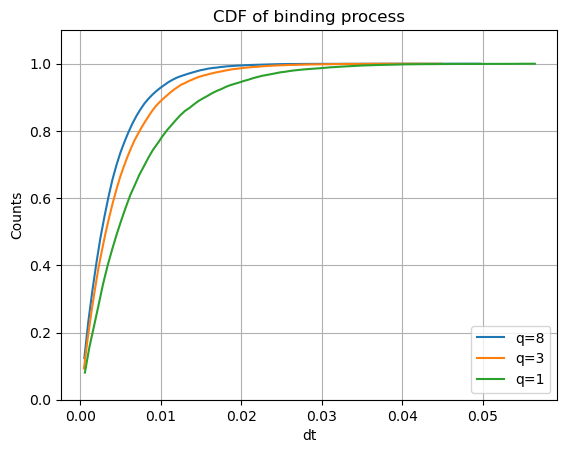

In [5]:
Q = [8,3,1]

fig, ax = plt.subplots(1,1)

for i, q in enumerate(Q):
    data, times, res, dt = line_sim(L,T, kon, koff, kstep, kq, q)
    Diff = get_binding_data(res, dt)
    x, y = normalised_cdf_histogramm(Diff)
    ax.plot(x, y, label=f"q={q}")

    ax.set( ylim = [0,1.1],xlabel="dt", ylabel="Counts", title="CDF of binding process")
    ax.legend()
    ax.grid()

In [6]:
Q = np.arange(1, 11)
lamda = np.zeros(10)
lamda_var = np.zeros_like(lamda)

for i, q in enumerate(Q):
    data, times, res, dt = line_sim(L,T, kon, koff, kstep, kq, q)
    lamda[i], lamda_var[i] = fit_cdf(res, dt, get_binding_data)

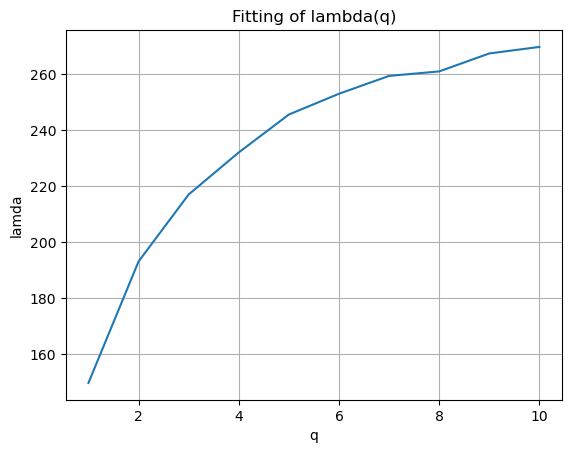

In [7]:
fig, ax = plt.subplots(1,1)
ax.plot(Q, lamda)
# ax.plot(Q, 100000*np.sqrt(lamda_var)/lamda)
ax.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax.grid()

In [5]:

def find_max_for_fixed_kon(L,T, kon, koff, kstep, kq, q, data_points=100):
    N=data_points
    Q = np.linspace(1.1,10,N)
    lamda = np.zeros(N)
    lamda_var = np.zeros(N)
    num_kins = np.zeros(N)

    for i in prange(len(Q)):
        data, times, res, dt = line_sim(L,T, kon, koff, 0, kq, Q[i])
        num_kins[i] = np.mean(np.sum(data[200:, :], axis=1))
        lamda[i], lamda_var[i] = fit_cdf(res, dt, get_stepping_data)
    semi_current = num_kins*lamda
    M = np.max(semi_current)
    idx = np.where(semi_current==M)[0][0]
    return M, Q[idx]

In [8]:
import concurrent.futures

In [6]:
def process(kon, q, i, j):
    global num_kins, lamda, lamda_var, L, T, koff, kstep, kq
    data, times, res, dt = line_sim(L,T, kon, koff, kstep, kq, q)
    num_kins[i, j] = np.mean(np.sum(data[200:, :], axis=1))
    lamda[i, j], lamda_var[i, j] = fit_cdf(res, dt, get_stepping_data)

In [ ]:
def get_binding_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==0)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

In [36]:
data, times, res, dt = line_sim(L,T, 1, koff, kstep, 1000, 10)

In [38]:
DT = np.cumsum(dt)

In [41]:
DT[-int(len(DT)/100)]

99.00131768002935

In [51]:
start = DT[-2*int(len(DT)/100)] # Start our timer at approx the last 1/100 of the simulation.
end = DT[-1] 

In [52]:
actual_time = end-start

In [53]:
a=np.where(res[-2*int(len(DT)/100):]==2)[0]

In [54]:
len(a)/actual_time

6249.879799313941

In [58]:
@njit
def calc_current(res, dt):
    DT = np.cumsum(dt)
    index = int(len(DT)/100)
    start = DT[-index]
    end = DT[-1] 
    a=np.where(res[-index:]==2)[0]
    return len(a)/(end-start)

In [60]:
calc_current(res, dt)

6225.1817403226

In [67]:
Nq=5
Nkon=20

Q = np.linspace(1.1,8,Nq)
KON = np.linspace(0.1,1.3,Nkon)

lamda = np.zeros((Nq,Nkon))
lamda_var = np.zeros_like(lamda)
num_kins = np.zeros_like(lamda)
current = np.zeros_like(lamda)

for i in range(len(Q)):
    for j in range(len(KON)):
        # process(KON[j], Q[i], i, j)
        data, times, res, dt = line_sim(L,T, KON[j], koff, kstep, 100, Q[i])
        num_kins[i, j] = np.mean(np.sum(data[200:, :], axis=1))
        lamda[i, j], lamda_var[i, j] = fit_cdf(res, dt, get_stepping_data)
        current[i,j] = calc_current(res,dt)
# semi_current = num_kins*lamda
# M = np.max(semi_current)
# idx = np.where(semi_current==M)[0][0]
semi_current = num_kins*lamda

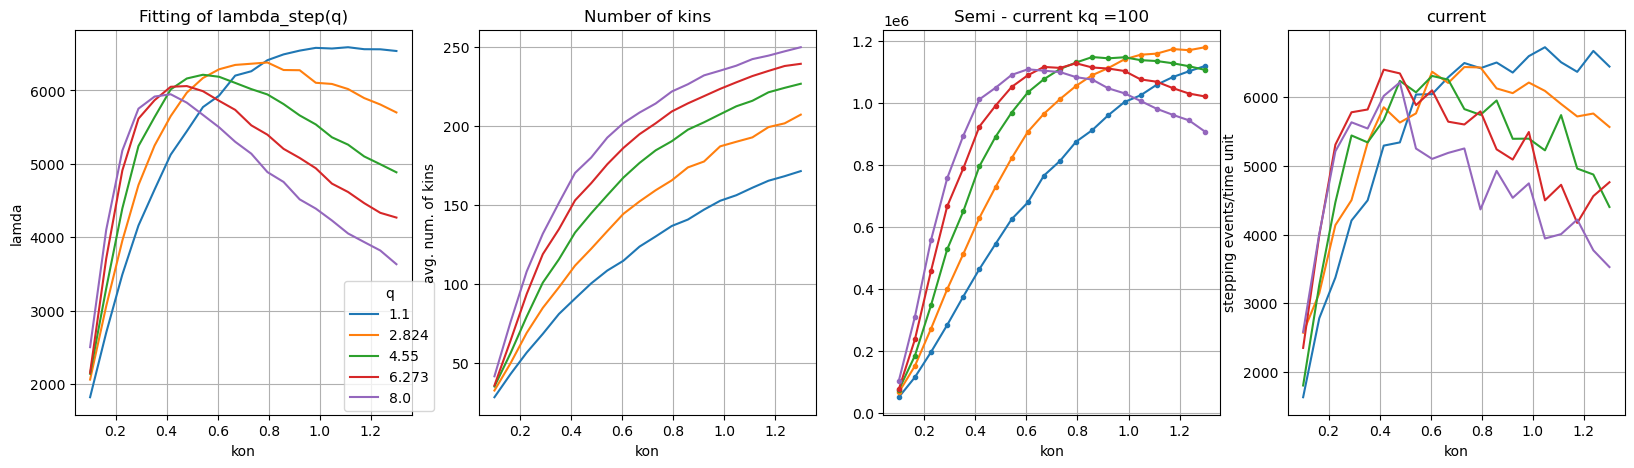

In [68]:
fig, (ax1, ax2, ax3,ax4) = plt.subplots(1,4, figsize=(20,5))

ax1.plot(KON, lamda.T, label = Q.astype(np.float16))
ax1.set(xlabel = "kon", ylabel = "lamda", title = "Fitting of lambda_step(q)")
ax1.grid()
ax1.legend(loc = (0.8,0.01),title="q")

ax2.plot(KON, num_kins.T)
ax2.set(xlabel = "kon", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()

semi_current = num_kins*lamda

ax3.plot(KON, semi_current.T, marker=".")
ax3.set(xlabel = "kon", ylabel = "", title = "Semi - current kq =100")
ax3.grid()

ax4.plot(KON, current.T)
ax4.set(xlabel = "kon", ylabel = "stepping events/time unit", title = "current")
ax4.grid()

In [69]:
fig.savefig("kon-q-100.png", dpi =300)

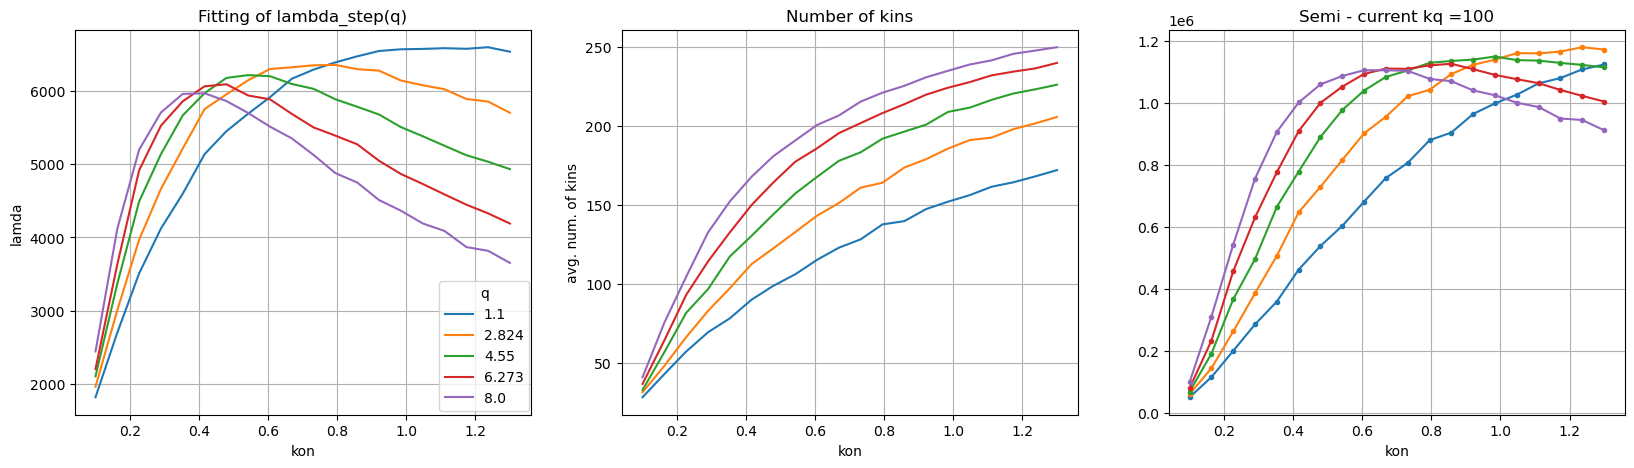

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))

ax1.plot(KON, lamda.T, label = Q.astype(np.float16))
ax1.set(xlabel = "kon", ylabel = "lamda", title = "Fitting of lambda_step(q)")
ax1.grid()
ax1.legend(loc = (0.8,0.01),title="q")

ax2.plot(KON, num_kins.T)
ax2.set(xlabel = "kon", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()

semi_current = num_kins*lamda

ax3.plot(KON, semi_current.T, marker=".")
ax3.set(xlabel = "kon", ylabel = "", title = "Semi - current kq =100")
ax3.grid()

In [30]:
fig.savefig("kon-q-1000.png", dpi =300)

In [25]:
Nq=20
Nkon=5

Q = np.linspace(1.1,8,Nq)
KON = np.linspace(0.1,1.3,Nkon)

lamda = np.zeros((Nq,Nkon))
lamda_var = np.zeros_like(lamda)
num_kins = np.zeros_like(lamda)

for i in range(len(Q)):
    for j in range(len(KON)):
        # process(KON[j], Q[i], i, j)
        data, times, res, dt = cyclic_sim(10,T, KON[j], koff, kstep, 1000, Q[i])
        num_kins[i, j] = np.mean(np.sum(data[200:, :], axis=1))
        lamda[i, j], lamda_var[i, j] = fit_cdf(res, dt, get_stepping_data)
# semi_current = num_kins*lamda
# M = np.max(semi_current)
# idx = np.where(semi_current==M)[0][0]
current = num_kins*lamda

In [6]:
# N_q=30


# Q = np.linspace(1.1,10,N)
# KON = np.linspace(1,100,N)

# lamda = np.zeros((N,N))
# lamda_var = np.zeros_like(lamda)
# num_kins = np.zeros_like(lamda)


# with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
#     for i in range(len(Q)):
#         for j in range(len(Q)):
#             executor.submit(process,KON[j], Q[i], i, j )
#             # process(KON[j], Q[i], i, j)

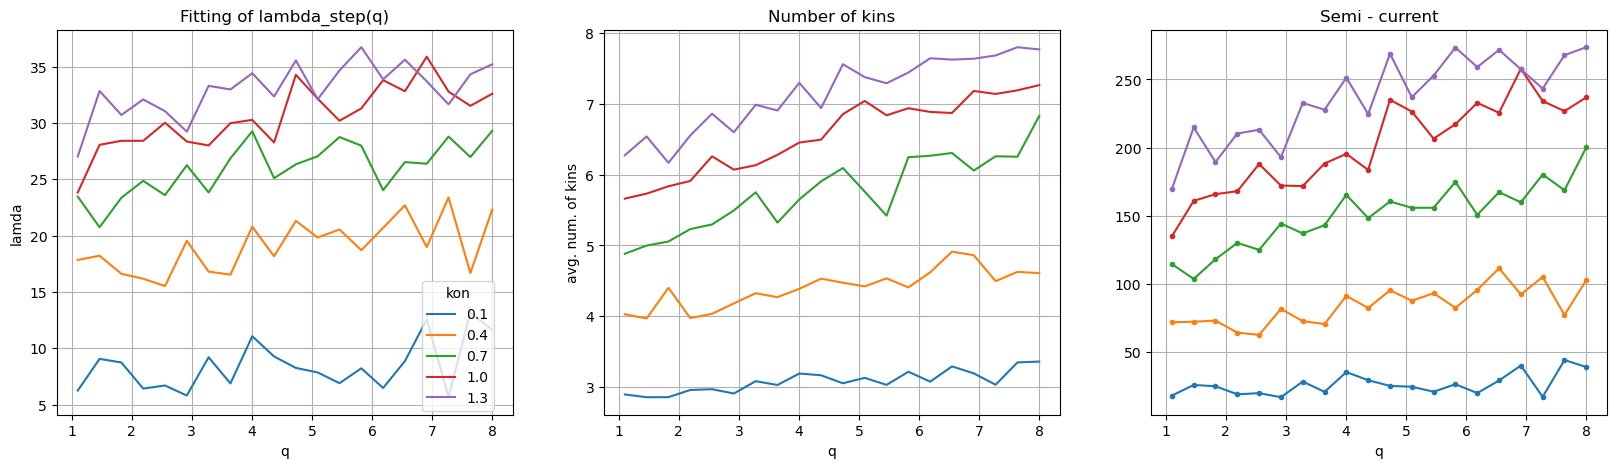

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))

ax1.plot(Q, lamda, label = KON.astype(np.float16))
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda_step(q)")
ax1.grid()
ax1.legend(loc = (0.8,0.01),title="kon")

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda, marker=".")
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()

In [34]:
fig.savefig("small_L_linear.png", dpi=300)

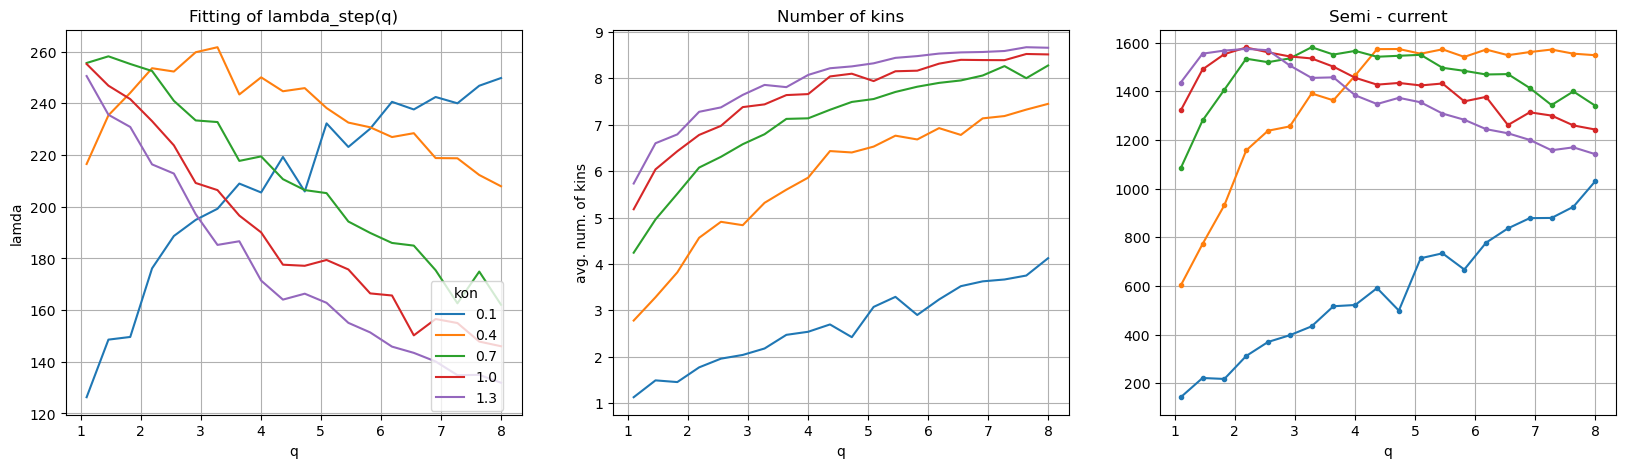

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))

ax1.plot(Q, lamda, label = KON.astype(np.float16))
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda_step(q)")
ax1.grid()
ax1.legend(loc = (0.8,0.01),title="kon")

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda, marker=".")
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()

In [37]:
fig.savefig("L_small_cyclic.png", dpi=300)

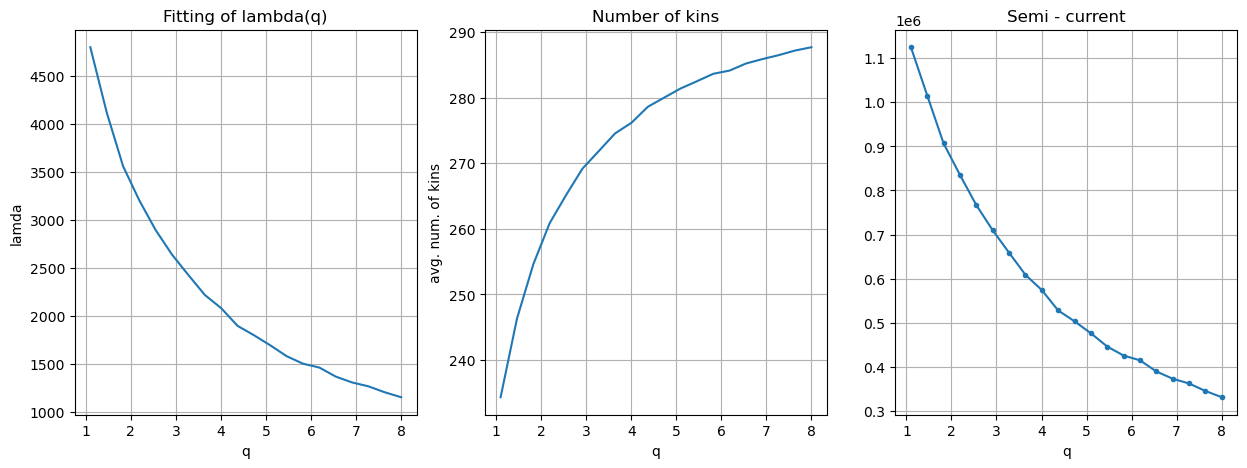

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))
ind = 1
ax1.plot(Q, lamda[:, ind])
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins[:, ind])
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, current[:, ind], marker=".")
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()

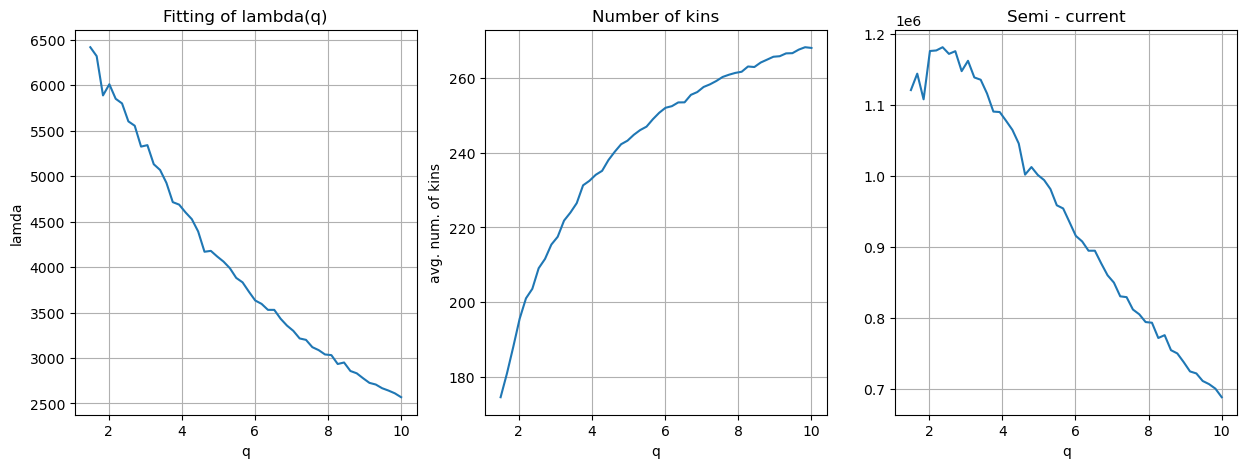

In [95]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1.plot(Q, lamda)
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda)
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()